## 1. Зачем вообще нужна функция активации?

Посмотрим на обычный слой:

```python
nn.Linear(13, 32)
```

Он выполняет линейное преобразование данных.

Если сделать:

```text
Linear → Linear → Linear
```

без функций активации, вся конструкция всё равно останется **одним большим линейным преобразованием**.

Поэтому между слоями добавляют нелинейность:

```text
Linear → ReLU → Linear → ReLU → Linear
```

Именно функции активации позволяют сети описывать **сложные нелинейные зависимости**.

# 2. Основные функции активации

Сегодня сравним:

### Для скрытых слоёв
- Sigmoid
- Tanh
- ReLU
- LeakyReLU
- Swish / SiLU

### Для выходного слоя
- Sigmoid — когда нужен один бинарный ответ / вероятность
- Softmax — когда нужно выбрать один класс из нескольких

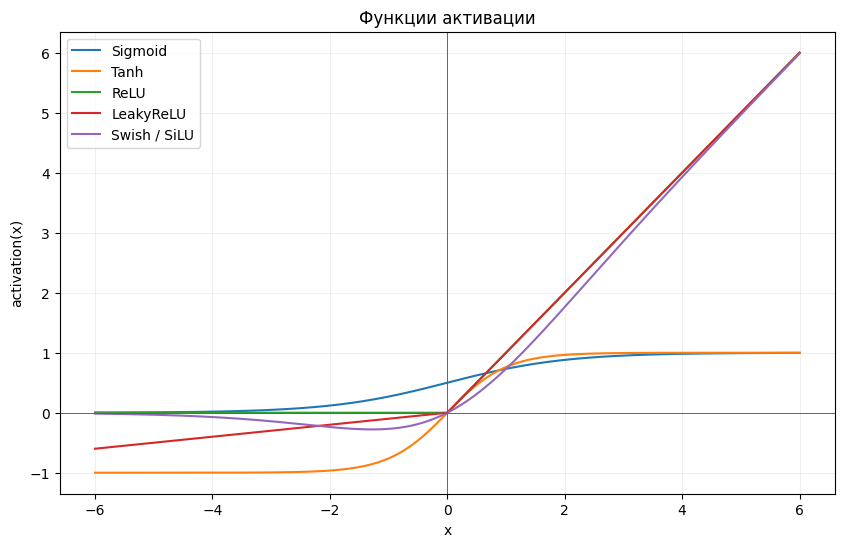

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

x = torch.linspace(-6, 6, 500)

sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = torch.relu(x)
leaky_relu = torch.nn.functional.leaky_relu(x, negative_slope=0.1)
swish = x * torch.sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")
plt.plot(x, leaky_relu, label="LeakyReLU")
plt.plot(x, swish, label="Swish / SiLU")
plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)
plt.grid(alpha=0.2)
plt.legend()
plt.title("Функции активации")
plt.xlabel("x")
plt.ylabel("activation(x)")
plt.show()

## 3. Sigmoid



Sigmoid переводит любое число в диапазон **от 0 до 1**.

Примеры:

```text
очень отрицательное число → почти 0
0 → 0.5
очень положительное число → почти 1
```

Поэтому Sigmoid очень удобно интерпретировать как **вероятность бинарного события**.

Например:

```text
0.12 → модель считает болезнь маловероятной
0.87 → модель считает наличие болезни более вероятным
```

### Но есть проблема

На больших положительных и отрицательных значениях график становится почти горизонтальным.

А если функция почти горизонтальна — её производная становится очень маленькой.

Это одна из причин **затухающего градиента**.

In [4]:
values = torch.tensor([-10., -3., 0., 3., 10.])
print(torch.sigmoid(values))

tensor([4.5398e-05, 4.7426e-02, 5.0000e-01, 9.5257e-01, 9.9995e-01])


## 4. Tanh

`tanh` похож на Sigmoid, но диапазон:

\[
[-1, 1]
\]

В отличие от Sigmoid, функция центрирована около нуля.

Но на больших по модулю значениях `tanh` тоже становится почти горизонтальной, поэтому проблема маленьких градиентов остаётся.

## 5. ReLU

\[
ReLU(x)=max(0,x)
\]

Очень простая функция:

```text
x < 0 → 0
x > 0 → x
```

ReLU долгое время стала стандартным выбором для скрытых слоёв, потому что на положительной части её градиент не уменьшается до очень маленьких значений.

Но есть другая проблема:

если нейрон постоянно попадает в отрицательную область, его выход равен 0 и градиент тоже может стать 0.

Это называют **dying ReLU**.

## 6. LeakyReLU

LeakyReLU пытается исправить проблему «мёртвых» ReLU.

В отрицательной области вместо полного нуля остаётся маленький наклон:

```text
ReLU:       -5 → 0
LeakyReLU:  -5 → -0.5   (если negative_slope=0.1)
```

То есть нейрон сохраняет возможность получать градиент даже в отрицательной области.

## 7. Swish / SiLU

Swish:

В PyTorch эта функция реализована как:

```python
nn.SiLU()
```

Она гладкая, не обнуляет полностью отрицательную часть и используется во многих современных архитектурах.

На этом занятии нам достаточно понимать:

**ReLU — простой и быстрый базовый вариант.  
LeakyReLU — оставляет небольшой градиент в отрицательной области.  
SiLU — более плавная современная альтернатива.**

# 8. Sigmoid и Softmax на ВЫХОДЕ

Здесь очень важно не путать скрытые и выходные слои.

### Бинарная классификация

Например:

```text
болезнь отсутствует / болезнь присутствует
```

Можно сделать **один выходной нейрон**.

После Sigmoid получим вероятность:

```text
0.08
0.42
0.91
```

и можем использовать порог, например `0.5`.

---

### Многоклассовая классификация

Например:

```text
кошка / собака / птица
```

Последний слой выдаёт 3 числа.

Softmax превращает их в вероятности, сумма которых равна 1.

In [5]:
logits = torch.tensor([2.0, 1.0, 0.2])
probabilities = torch.softmax(logits, dim=0)

print("Logits:", logits)
print("Softmax:", probabilities)
print("Сумма:", probabilities.sum())

Logits: tensor([2.0000, 1.0000, 0.2000])
Softmax: tensor([0.6522, 0.2399, 0.1078])
Сумма: tensor(1.)


## Важный практический момент PyTorch

Во время обучения **не всегда нужно вручную ставить Sigmoid или Softmax в модель**.

Для бинарной классификации удобно:

```python
nn.Linear(..., 1)
criterion = nn.BCEWithLogitsLoss()
```

`BCEWithLogitsLoss` сама объединяет вычисления Sigmoid и Binary Cross Entropy более стабильным способом.

А когда нам понадобится показать вероятность человеку:

```python
probability = torch.sigmoid(logit)
```

Для многоклассовой классификации `CrossEntropyLoss` также ожидает **сырые logits**, поэтому Softmax перед ней обычно не ставят.

# 9. Что значит «затухающий градиент»?

Во время `backward()` PyTorch вычисляет, насколько каждый параметр повлиял на ошибку.

В глубокой сети эта информация проходит через много слоёв.

Представим, что на каждом шаге градиент уменьшается примерно в 10 раз:

```text
1
0.1
0.01
0.001
0.0001
0.00001
```

До первых слоёв доходит почти **ноль**.

Они практически перестают изменяться.

Это и называют **vanishing gradient — затухающий градиент**.

In [6]:
value = 1.0

print("Затухание:")
for layer in range(1, 11):
    value *= 0.2
    print(f"После слоя {layer:2d}: {value:.10f}")

Затухание:
После слоя  1: 0.2000000000
После слоя  2: 0.0400000000
После слоя  3: 0.0080000000
После слоя  4: 0.0016000000
После слоя  5: 0.0003200000
После слоя  6: 0.0000640000
После слоя  7: 0.0000128000
После слоя  8: 0.0000025600
После слоя  9: 0.0000005120
После слоя 10: 0.0000001024


# 10. Что значит «взрывающийся градиент»?

Теперь обратная ситуация.

Если при прохождении через слои значения постоянно увеличиваются:

```text
1
2
4
8
16
32
...
```

градиент может стать огромным.

Тогда веса начинают изменяться слишком резко:

- loss скачет;
- обучение становится нестабильным;
- могут появиться `inf` или `nan`.

Это **exploding gradient — взрывающийся градиент**.

In [7]:
value = 1.0

print("Взрыв:")
for layer in range(1, 11):
    value *= 2.5
    print(f"После слоя {layer:2d}: {value:.4f}")

Взрыв:
После слоя  1: 2.5000
После слоя  2: 6.2500
После слоя  3: 15.6250
После слоя  4: 39.0625
После слоя  5: 97.6562
После слоя  6: 244.1406
После слоя  7: 610.3516
После слоя  8: 1525.8789
После слоя  9: 3814.6973
После слоя 10: 9536.7432


## Почему функции активации связаны с градиентами?

Backpropagation использует производные функций.

Если производная много раз подряд маленькая — градиент затухает.

Поэтому Sigmoid и Tanh в очень глубоких скрытых слоях могут создавать проблемы.

ReLU на положительной области имеет простой стабильный градиент, поэтому обучение глубоких сетей стало намного удобнее.

Но ReLU тоже не идеальна — в отрицательной части её градиент равен нулю.

Именно поэтому существуют LeakyReLU, ELU, GELU, SiLU и другие варианты.

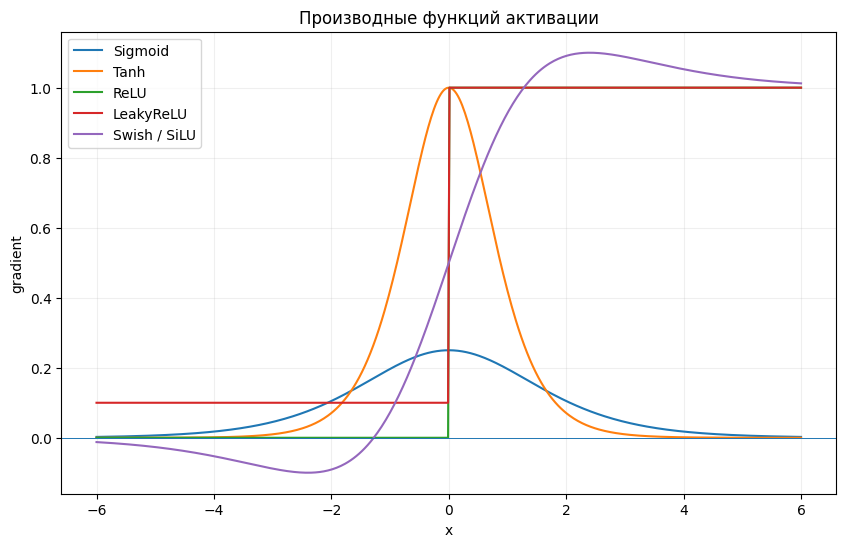

In [8]:
# Посмотрим на производные функций автоматически через autograd

x = torch.linspace(-6, 6, 500, requires_grad=True)

functions = {
    "Sigmoid": torch.sigmoid(x),
    "Tanh": torch.tanh(x),
    "ReLU": torch.relu(x),
    "LeakyReLU": torch.nn.functional.leaky_relu(x, 0.1),
    "Swish / SiLU": x * torch.sigmoid(x)
}

plt.figure(figsize=(10, 6))

for name, y in functions.items():
    grad = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        retain_graph=True
    )[0]

    plt.plot(x.detach(), grad.detach(), label=name)

plt.axhline(0, linewidth=0.7)
plt.grid(alpha=0.2)
plt.legend()
plt.title("Производные функций активации")
plt.xlabel("x")
plt.ylabel("gradient")
plt.show()

# 11.  Heart Disease

Теперь используем всё это в реальной задаче бинарной классификации.

Будем прогнозировать:

```text
0 — отсутствие заболевания
1 — наличие заболевания
```

Будем использовать классический **UCI Heart Disease** dataset.

В нём используются признаки вроде:

- возраст;
- пол;
- тип боли в груди;
- давление в состоянии покоя;
- холестерин;
- максимальный пульс;
- стенокардия при нагрузке;
- показатели ST;
- и другие признаки.

В исходном UCI Heart Disease целевая переменная принимает значения `0–4`.  
Для учебной бинарной задачи:

```text
0 → заболевание отсутствует
1,2,3,4 → заболевание присутствует
```

## 12. Загружаем данные

Если библиотека `ucimlrepo` ещё не установлена, выполните следующую ячейку.

In [9]:
# при необходимости:
!pip install -q ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

heart = fetch_ucirepo(id=45)

X = heart.data.features.copy()
y = heart.data.targets.copy()

print("Размер X:", X.shape)
print("Размер y:", y.shape)

display(X.head())
display(y.head())

Размер X: (303, 13)
Размер y: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


## 13. Посмотрим на данные

Перед нейросетью всегда нужно хотя бы быстро проверить:

- размеры;
- типы;
- пропуски;
- распределение целевого класса.

Нейросеть не отменяет обычный анализ данных.

In [11]:
print(X.info())
print("\nПропуски:")
display(X.isna().sum().sort_values(ascending=False).head(15))

target_col = y.columns[0]
print("\nИсходные значения target:")
print(y[target_col].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None

Пропуски:


ca          4
thal        2
cp          0
sex         0
age         0
chol        0
trestbps    0
fbs         0
restecg     0
exang       0
thalach     0
slope       0
oldpeak     0
dtype: int64


Исходные значения target:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [12]:
# Превращаем задачу в бинарную:
# 0 = нет заболевания
# 1 = есть заболевание

y_binary = (y[target_col] > 0).astype(int)

print(y_binary.value_counts())

num
0    164
1    139
Name: count, dtype: int64


## 14. Подготовка данных

Некоторые признаки категориальные, а некоторые числовые.

Для учебного примера:

1. объединим X и y;
2. обработаем `?` и пропуски;
3. используем one-hot encoding для категориальных признаков;
4. разделим данные на train/test;
5. масштабируем числовые значения.

> Важно: preprocessing обучаем **только на train**, чтобы не подсматривать в test.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = X.replace("?", np.nan)

# В UCI часть признаков помечены как categorical.
# Для понятного учебного примера перечислим их явно.
categorical_columns = [
    col for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
    if col in X.columns
]

numeric_columns = [col for col in X.columns if col not in categorical_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_columns),
    ("cat", categorical_transformer, categorical_columns)
])

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("После preprocessing:")
print("Train:", X_train_ready.shape)
print("Test:", X_test_ready.shape)

После preprocessing:
Train: (242, 25)
Test: (61, 25)


## 15. Переводим данные в Tensor

PyTorch работает с Tensor.

Для `BCEWithLogitsLoss` target должен быть вещественным (`float`), поэтому `y` тоже переводим в `float32`.

In [14]:
X_train_tensor = torch.tensor(X_train_ready, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_ready, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([242, 25])
torch.Size([242, 1])


# 16. Собираем нейронную сеть

Сделаем простую архитектуру:

```text
признаки
   ↓
Linear
   ↓
ReLU
   ↓
Linear
   ↓
ReLU
   ↓
Linear(1)
   ↓
logit
```

Почему последний слой имеет **1 нейрон**?

Потому что у нас бинарная задача.

Почему в конце нет Sigmoid?

Потому что во время обучения используем `BCEWithLogitsLoss`.

In [27]:
class HeartNet(nn.Module):
    def __init__(self, input_size, activation=nn.ReLU):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            activation(),
            nn.Linear(128, 64),
            activation(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

model = HeartNet(X_train_tensor.shape[1])

print(model)

HeartNet(
  (network): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


# 17. Loss и optimizer

Используем:

```python
BCEWithLogitsLoss
```

для бинарной классификации.

И `Adam` как удобный стартовый оптимизатор.

In [28]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1
)

# 18. Обучаем модель

Вспоминаем главный цикл:

```text
zero_grad
→ forward
→ loss
→ backward
→ optimizer.step
```

In [29]:
epochs = 300
loss_history = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(logits, y_train_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {loss.item():.4f}"
        )

Epoch  50 | Loss: 0.0617
Epoch 100 | Loss: 0.0168
Epoch 150 | Loss: 0.0086
Epoch 200 | Loss: 0.0067
Epoch 250 | Loss: 0.0052
Epoch 300 | Loss: 0.0040


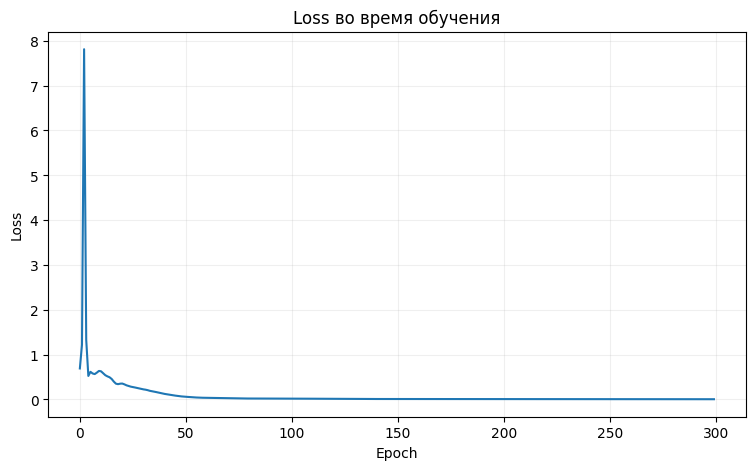

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(loss_history)
plt.title("Loss во время обучения")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.show()

# 19. Проверяем модель

Во время проверки:

```python
model.eval()
torch.no_grad()
```

Получаем logits.

Чтобы превратить logit в вероятность, применяем:

```python
torch.sigmoid(logit)
```

Затем:

```text
probability >= 0.5 → класс 1
probability < 0.5 → класс 0
```

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.5).int()

y_true = y_test_tensor.numpy().astype(int).ravel()
y_pred = predictions.numpy().ravel()

print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy : 0.803
Precision: 0.767
Recall   : 0.821
F1       : 0.793

Confusion matrix:
[[26  7]
 [ 5 23]]


## Почему недостаточно только Accuracy?

В медицинской задаче особенно важно понимать разницу:

- **False Positive** — модель сказала «есть болезнь», хотя её нет;
- **False Negative** — модель сказала «болезни нет», хотя заболевание есть.

В реальных медицинских системах цена разных типов ошибок может быть совершенно разной.

Поэтому здесь мы смотрим не только `Accuracy`, но и `Precision`, `Recall`, `F1`.

Но ещё раз: эта учебная модель **не предназначена для медицинских решений**.

# 20. Сравним разные функции активации

Теперь самое полезное.

Будем использовать **одинаковую архитектуру**, одинаковые данные и одинаковый optimizer.

Меняется только функция активации.

Сравним:

- Sigmoid
- Tanh
- ReLU
- LeakyReLU
- SiLU

In [32]:
from sklearn.metrics import accuracy_score

activation_functions = {
    "Sigmoid": nn.Sigmoid,
    "Tanh": nn.Tanh,
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "SiLU": nn.SiLU
}

results = {}
histories = {}

torch.manual_seed(42)

for name, activation in activation_functions.items():

    torch.manual_seed(42)

    current_model = HeartNet(
        X_train_tensor.shape[1],
        activation=activation
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=0.1
    )

    history = []

    for epoch in range(300):

        current_model.train()
        optimizer.zero_grad()

        logits = current_model(X_train_tensor)
        loss = criterion(logits, y_train_tensor)

        loss.backward()
        optimizer.step()

        history.append(loss.item())

    current_model.eval()

    with torch.no_grad():
        probs = torch.sigmoid(current_model(X_test_tensor))
        preds = (probs >= 0.5).int().numpy().ravel()

    accuracy = accuracy_score(y_test, preds)

    results[name] = accuracy
    histories[name] = history

results

{'Sigmoid': 0.8360655737704918,
 'Tanh': 0.8688524590163934,
 'ReLU': 0.8524590163934426,
 'LeakyReLU': 0.819672131147541,
 'SiLU': 0.819672131147541}

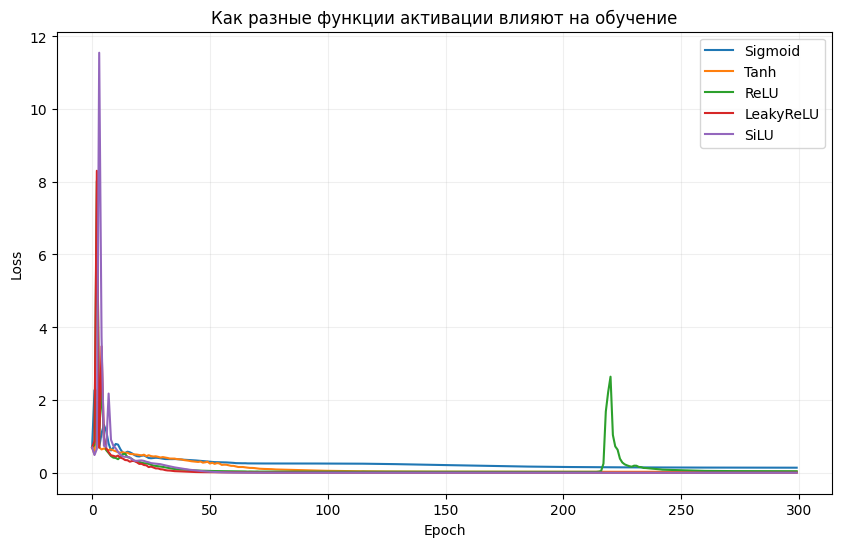

In [33]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history, label=name)

plt.title("Как разные функции активации влияют на обучение")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [26]:
results_df = pd.DataFrame(
    {
        "Activation": list(results.keys()),
        "Test Accuracy": list(results.values())
    }
).sort_values(
    "Test Accuracy",
    ascending=False
)

display(results_df)

,Activation,Test Accuracy
4,SiLU,0.868852
3,LeakyReLU,0.836066
1,Tanh,0.836066
2,ReLU,0.819672
0,Sigmoid,0.803279


## Важный вывод эксперимента

Не нужно делать вывод:

> «Функция X всегда лучше функции Y».

Результат зависит от:

- данных;
- архитектуры;
- инициализации;
- optimizer;
- learning rate;
- количества эпох;
- размера выборки.

Главная цель эксперимента — увидеть, что **функция активации реально влияет на процесс обучения**.

# 21. Эксперименты для студентов

### Эксперимент 1
Поменять:

```python
lr=0.001
```

на:

```python
lr=0.1
```

Посмотреть, как изменяется loss.

---

### Эксперимент 2
Увеличить сеть:

```text
32 → 128
16 → 64
```

Стало ли качество значительно лучше?

---

### Эксперимент 3
Добавить:

```python
nn.Dropout(0.3)
```

между скрытыми слоями.

---

### Эксперимент 4
Заменить Adam на SGD.

---

### Эксперимент 5
Изменить порог:

```text
0.5 → 0.4
0.5 → 0.6
```

и сравнить Precision / Recall.

Это очень хороший пример того, что **порог классификации тоже влияет на типы ошибок**.

# Итог занятия

Сегодня нужно запомнить несколько вещей.

### 1.
Функция активации добавляет нелинейность.

### 2.
Для скрытых слоёв часто используются:

```text
ReLU
LeakyReLU
SiLU
```

Sigmoid и Tanh тоже существуют, но в глубоких скрытых слоях могут сильнее страдать от затухания градиента.

### 3.
Для бинарного выхода удобно использовать Sigmoid.

### 4.
Для нескольких взаимоисключающих классов — Softmax.

### 5.
Vanishing gradient:

```text
градиент → почти 0
```

ранние слои почти перестают обучаться.

### 6.
Exploding gradient:

```text
градиент → огромное значение
```

обучение становится нестабильным.

### 7.
В PyTorch для бинарной классификации удобно:

```python
Linear(..., 1)
BCEWithLogitsLoss()
```

а Sigmoid применять уже при получении вероятности.

In [34]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 500
styles = ['Агрессивный','Тактический', 'Осторожный']

n_per = N // 3
labels = np.array([0]*n_per + [1]*n_per + [2]*(N - 2*n_per))
np.random.shuffle(labels)

def gen_player(style):
    if style == 0: 
        kills = np.random.normal(18, 5.5)
        deaths = np.random.normal(14, 5)
        accuracy = np.random.normal(38, 11)
        headshot = np.random.normal(15, 8)
        damage = np.random.normal(2600, 650)
        distance = np.random.normal(3200, 800)
        time_alive = np.random.normal(220, 90)
        shots_fired = np.random.normal(420, 120)
        healing = np.random.normal(80, 55)
        matches = np.random.randint(20, 400)

    elif style == 1:  
        kills = np.random.normal(13, 4)
        deaths = np.random.normal(8, 3.2)
        accuracy = np.random.normal(55, 10)
        headshot = np.random.normal(35, 10)
        damage = np.random.normal(2100, 500)
        distance = np.random.normal(2000, 550)
        time_alive = np.random.normal(420, 100)
        shots_fired = np.random.normal(230, 80)
        healing = np.random.normal(150, 65)
        matches = np.random.randint(20, 400)

    else: 
        kills = np.random.normal(6, 3)
        deaths = np.random.normal(4, 2.2)
        accuracy = np.random.normal(45, 12)
        headshot = np.random.normal(20, 9)
        damage = np.random.normal(1100, 380)
        distance = np.random.normal(900, 380)
        time_alive = np.random.normal(600, 120)
        shots_fired = np.random.normal(120, 55)
        healing = np.random.normal(260, 90)
        matches = np.random.randint(20, 400)


    shots_fired = max(shots_fired, 10)
    accuracy = np.clip(accuracy, 5, 95)
    shots_hit = shots_fired * (accuracy / 100.0) + np.random.normal(0, 8)
    shots_hit = np.clip(shots_hit, 0, shots_fired)

    return {
        'Kills': max(kills, 0),
        'Deaths': max(deaths, 0.5),
        'Accuracy': np.clip(accuracy, 1, 99),
        'HeadshotPercent': np.clip(headshot, 0, 80),
        'DamagePerMatch': max(damage, 50),
        'DistanceTravelled': max(distance, 50),
        'TimeAlive': np.clip(time_alive, 20, 900),
        'ShotsFired': shots_fired,
        'ShotsHit': shots_hit,
        'HealingUsed': max(healing, 0),
        'MatchesPlayed': matches,
    }


rows = [gen_player(s) for s in labels]
df = pd.DataFrame(rows)
df['PlayStyle'] = [styles[s] for s in labels]

n_swap = int(0.03 * len(df))
swap_idx = np.random.choice(df.index, size=n_swap, replace=False)
for i in swap_idx:
    other = [s for s in styles if s != df.loc[i, 'PlayStyle']]
    df.loc[i, 'PlayStyle'] = np.random.choice(other)

df = df.round(2)
print(df.shape)                                  
print(df.groupby('PlayStyle').mean(numeric_only=True).round(1))

(500, 12)
             Kills  Deaths  Accuracy  HeadshotPercent  DamagePerMatch  \
PlayStyle                                                               
Агрессивный   17.7    14.0      37.9             15.8          2608.2   
Осторожный     6.3     4.4      44.5             20.5          1133.5   
Тактический   13.6     7.9      54.5             33.0          2080.3   

             DistanceTravelled  TimeAlive  ShotsFired  ShotsHit  HealingUsed  \
PlayStyle                                                                      
Агрессивный             3091.2      231.0       415.9     155.3         80.0   
Осторожный               901.5      591.3       130.8      57.3        261.6   
Тактический             2028.6      397.0       230.5     125.5        149.2   

             MatchesPlayed  
PlayStyle                   
Агрессивный          209.9  
Осторожный           218.6  
Тактический          213.4  


In [35]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['Kills','Deaths','Accuracy','HeadshotPercent','DamagePerMatch',
                 'DistanceTravelled','TimeAlive','ShotsFired','ShotsHit',
                 'HealingUsed','MatchesPlayed']

style_to_idx = {s: i for i, s in enumerate(styles)}

X = df[feature_cols].values.astype(np.float32)
y = df['PlayStyle'].map(style_to_idx).values.astype(np.int64)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [36]:
class PlayerStyleNet(nn.Module):
    def __init__(self, in_features, activation_layer):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            activation_layer(),
            nn.Linear(32, 16),
            activation_layer(),
            nn.Linear(16, 3)   
            
        )

    def forward(self, x):
        return self.net(x)  

In [37]:
activations = {
    'Sigmoid':   nn.Sigmoid,
    'Tanh':      nn.Tanh,
    'ReLU':      nn.ReLU,
    'LeakyReLU': lambda: nn.LeakyReLU(0.1),
    'SiLU':      nn.SiLU,
}

EPOCHS = 200
results = {}

for name, act in activations.items():
    torch.manual_seed(0)
    model = PlayerStyleNet(len(feature_cols), act)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()  

    train_losses, test_accs = [], []
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).argmax(dim=1)
            acc = (preds == y_test_t).float().mean().item()
            test_accs.append(acc)

    results[name] = {
        'model': model,
        'train_losses': train_losses,
        'test_accs': test_accs,
        'final_loss': train_losses[-1],
        'final_acc': test_accs[-1],
    }
    print(f"{name:10s} | train loss: {train_losses[-1]:.4f} | test accuracy: {test_accs[-1]*100:.2f}%")

best_name, best_data = max(results.items(), key=lambda kv: kv[1]['final_acc'])
best_model = best_data['model']
print("\nЛучшая активация:", best_name, f"(acc={best_data['final_acc']*100:.2f}%)")

Sigmoid    | train loss: 0.1637 | test accuracy: 98.00%
Tanh       | train loss: 0.0674 | test accuracy: 97.00%
ReLU       | train loss: 0.0092 | test accuracy: 96.00%
LeakyReLU  | train loss: 0.0177 | test accuracy: 95.00%
SiLU       | train loss: 0.0133 | test accuracy: 94.00%

Лучшая активация: Sigmoid (acc=98.00%)


In [38]:
def check_player(model, **kwargs):

    x = np.array([[kwargs[c] for c in feature_cols]], dtype=np.float32)
    x_s = scaler.transform(x)              
    x_t = torch.tensor(x_s, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        logits = model(x_t)
        probs = torch.softmax(logits, dim=1).numpy()[0]   

    result = {styles[i]: round(float(probs[i]) * 100, 1) for i in range(3)}
    return dict(sorted(result.items(), key=lambda kv: -kv[1]))  

print(check_player(best_model,
    Kills=13, Deaths=8, Accuracy=55, HeadshotPercent=35, DamagePerMatch=2100,
    DistanceTravelled=2000, TimeAlive=420, ShotsFired=230, ShotsHit=126,
    HealingUsed=150, MatchesPlayed=200))

{'Тактический': 99.4, 'Осторожный': 0.5, 'Агрессивный': 0.1}


In [39]:
print(check_player(best_model,
    Kills=10, Deaths=3, Accuracy=85, HeadshotPercent=70, DamagePerMatch=2400,
    DistanceTravelled=600, TimeAlive=700, ShotsFired=40, ShotsHit=34,
    HealingUsed=200, MatchesPlayed=150))

print(check_player(best_model,
    Kills=25, Deaths=20, Accuracy=15, HeadshotPercent=5, DamagePerMatch=2800,
    DistanceTravelled=3500, TimeAlive=180, ShotsFired=900, ShotsHit=135,
    HealingUsed=30, MatchesPlayed=250))

print(check_player(best_model,
    Kills=1, Deaths=1, Accuracy=50, HeadshotPercent=10, DamagePerMatch=150,
    DistanceTravelled=400, TimeAlive=850, ShotsFired=15, ShotsHit=7,
    HealingUsed=300, MatchesPlayed=100))

{'Тактический': 89.1, 'Осторожный': 10.2, 'Агрессивный': 0.7}
{'Агрессивный': 97.0, 'Тактический': 1.7, 'Осторожный': 1.3}
{'Осторожный': 98.3, 'Агрессивный': 0.9, 'Тактический': 0.8}


In [40]:
rng = np.random.default_rng(0)
mins, maxs = X_train.min(axis=0), X_train.max(axis=0)

best_case, best_entropy, best_probs = None, -1, None

for _ in range(200_000):
    sample = mins + rng.random(len(feature_cols)) * (maxs - mins)
    x_s = scaler.transform(sample.reshape(1, -1))
    x_t = torch.tensor(x_s, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.softmax(best_model(x_t), dim=1).numpy()[0]

    entropy = -(probs * np.log(probs + 1e-9)).sum()
    if entropy > best_entropy:
        best_entropy, best_case, best_probs = entropy, sample, probs

print("Найденный 'неопределившийся' игрок:")
for c, v in zip(feature_cols, best_case):
    print(f"  {c}: {v:.1f}")
print("Вероятности:", {styles[i]: round(float(best_probs[i])*100, 1) for i in range(3)})

Найденный 'неопределившийся' игрок:
  Kills: 21.4
  Deaths: 3.2
  Accuracy: 38.1
  HeadshotPercent: 42.1
  DamagePerMatch: 3736.0
  DistanceTravelled: 2920.4
  TimeAlive: 591.9
  ShotsFired: 465.3
  ShotsHit: 76.6
  HealingUsed: 457.9
  MatchesPlayed: 265.2
Вероятности: {'Агрессивный': 33.3, 'Тактический': 33.1, 'Осторожный': 33.5}
